In [128]:
import torch
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))
    print("Versão CUDA do PyTorch:", torch.version.cuda)




CUDA disponível: True
Nome da GPU: NVIDIA GeForce GTX 1650
Versão CUDA do PyTorch: 12.1


# Parâmetros
Dimensão do modelo reduzido



In [129]:
new_dimension = 10

# Treinamento

## Primeira Etapa
- Carregar o torch
- Converter a imagem para tensor
- Carregar o dataset de treinamento (MNIST)
- Iterar sobre os dados e construir os batchs

In [130]:
from torchvision import datasets, transforms
import os

transform = transforms.Compose([
    transforms.Grayscale(),     
    transforms.Resize((75, 100)),
    transforms.ToTensor()
])

!ls CNN_letter_Dataset/test

test_data  = datasets.ImageFolder(root="CNN_letter_Dataset/test", transform=transform)
train_data  = datasets.ImageFolder(root="CNN_letter_Dataset/train", transform=transform)

# --- DataLoaders ---
train_loader = torch.utils.data.DataLoader(train_data, batch_size=10, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=10, shuffle=False)

# --- Informações básicas ---
print(f"Total de imagens de treino: {len(train_data)}")
print(f"Total de imagens de teste:  {len(test_data)}")
print(f"Classes encontradas: {train_data.classes}")
print(f"Mapeamento classes → índices: {train_data.class_to_idx}")

0  2  4  6  8  A  C  E	G  I  K  M  P  R  T  V	X  Z
1  3  5  7  9  B  D  F	H  J  L  N  Q  S  U  W	Y
Total de imagens de treino: 28400
Total de imagens de teste:  7100
Classes encontradas: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Mapeamento classes → índices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'I': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'P': 24, 'Q': 25, 'R': 26, 'S': 27, 'T': 28, 'U': 29, 'V': 30, 'W': 31, 'X': 32, 'Y': 33, 'Z': 34}


#### Exemplo de dado do dataset MNIST

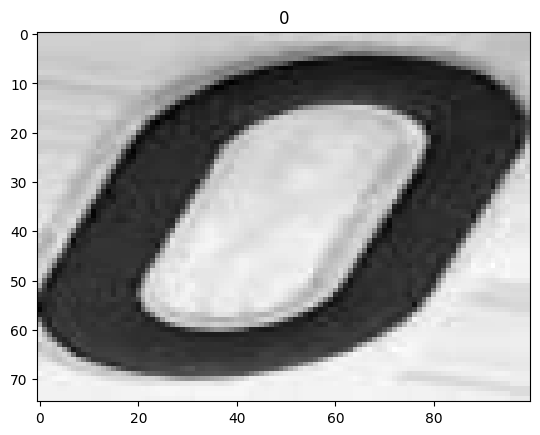

In [131]:
# A segunda célula (UAnytswpbzVZ) importa a biblioteca matplotlib para plotagem,
# seleciona a primeira imagem e seu rótulo do conjunto de dados de treinamento,
#exibe a imagem em escala de cinza e define o título do plot com o rótulo correspondente.

import matplotlib.pyplot as plt

img, label = train_data[0]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(train_data.classes[label])
plt.show()


## Segunda Etapa
Construir a arquitetura da rede
- Entrada
- Número de classes
- Modelo Sequencia
- Uma camada linear

In [132]:
# A terceira célula (-01hOQsnb5yA) importa módulos do torch.nn para construir a arquitetura do modelo,
# define o tamanho de entrada e o número de classes, e cria um modelo sequencial com uma camada linear
# de entrada para 10 classes (saída). Finalmente, imprime a estrutura do modelo.

from torch.nn import Sequential, Linear, ReLU, Flatten

tam_entrada =  75 * 100 
n_classes = len(train_data.classes)

# Modelo com apenas uma camada linear
# model = Sequential(Linear(tam_entrada, 128), ReLU(), Linear(128, 10))
model = Sequential(
    Flatten(),            
    Linear(tam_entrada, n_classes)
)
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=7500, out_features=35, bias=True)
)


## Terceira Etapa
Treinamento do modelo

- com função de perda e otimizador definidos
- faz o loop de treinamento pelas epocas definidas
- atualiza pesos com *retropropagation*
- calcula perda e atualiza pesos do modelo

In [133]:
import torch
from tqdm import tqdm

# --- Configurações ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 5
losses = []

# --- Loop de treino ---
for epoch in range(epochs):
    print(f'Epoch: {epoch+1}/{epochs}')
    batch_loss = 0

    for img_batch, label_batch in tqdm(train_loader):
        img_batch = img_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad()
        output = model(img_batch)       # Flatten já está no modelo
        loss = criterion(output, label_batch)
        batch_loss += loss.item()

        loss.backward()
        optimizer.step()

    losses.append(batch_loss / len(train_loader))
    print(f"Loss média da epoch: {losses[-1]:.4f}")


Epoch: 1/5


100%|███████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:35<00:00, 79.52it/s]


Loss média da epoch: 0.9969
Epoch: 2/5


100%|██████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:25<00:00, 111.12it/s]


Loss média da epoch: 0.4328
Epoch: 3/5


...

Loss média da epoch: 0.3358
Epoch: 4/5


100%|██████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:21<00:00, 129.84it/s]


Loss média da epoch: 0.2838
Epoch: 5/5


100%|██████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:21<00:00, 130.32it/s]

Loss média da epoch: 0.2527


In [134]:
# O print(losses) irá exibir uma lista de números. Cada número nessa lista representa a
# média da função de perda calculada ao final de cada época de treinamento.
# O valor da perda geralmente diminui ao longo das épocas, indicando que o modelo está aprendendo a fazer previsões melhores.

print(losses)

# [0.5347098572583249, 0.35873828949096304, 0.3306599416344737, 0.3162760896642382, 0.30684097594651394]

[0.9969443926745107, 0.4327714200616932, 0.33577971415672925, 0.2838339439462083, 0.25274460774544677]


# Analise Importancia Pixels
Selecionar quais são os pixels mais importantes para a saída, para poder diminuir o modelo

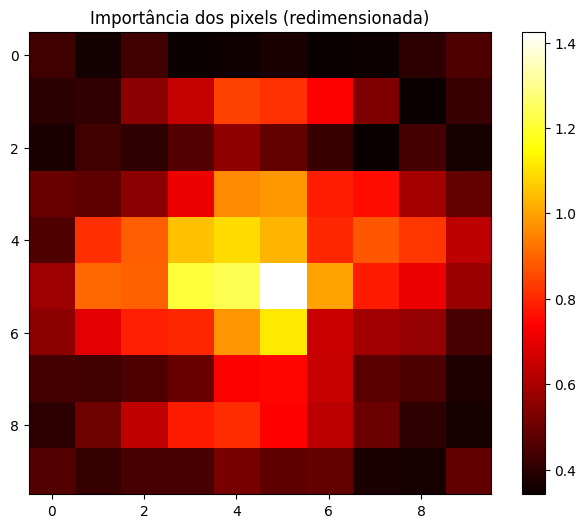

In [135]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Pegando os pesos da primeira camada Linear
weights = model[1].weight.data  # model[0] = Flatten, model[1] = Linear

# --- Calcular importância dos pixels ---
pixel_importance = torch.sum(torch.abs(weights), dim=0).reshape(75, 100)

# Redimensiona para new_dimension x new_dimension
pixel_importance_resized = F.interpolate(
    pixel_importance.unsqueeze(0).unsqueeze(0),  # [1,1,H,W]
    size=(new_dimension, new_dimension),
    mode='bilinear',
    align_corners=False
).squeeze()  # remove batch e canal

pixel_importance = pixel_importance_resized  # sobrescreve

# --- Plotar ---
plt.figure(figsize=(8, 6))
plt.imshow(pixel_importance.cpu(), cmap='hot')
plt.colorbar()
plt.title("Importância dos pixels (redimensionada)")
plt.show()


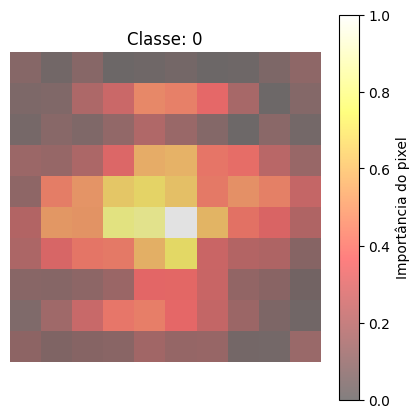

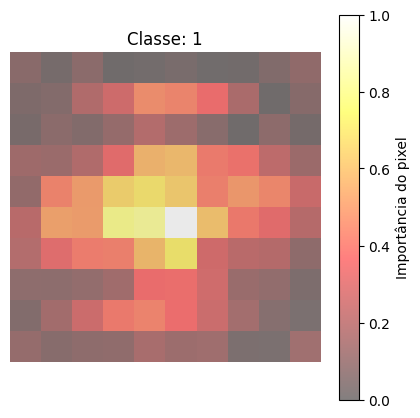

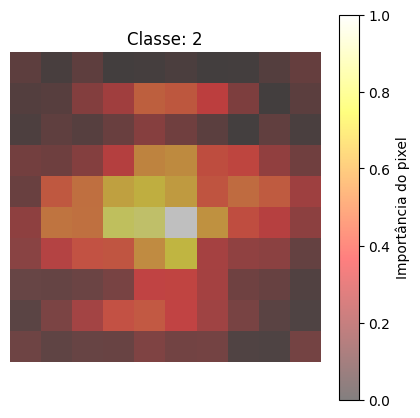

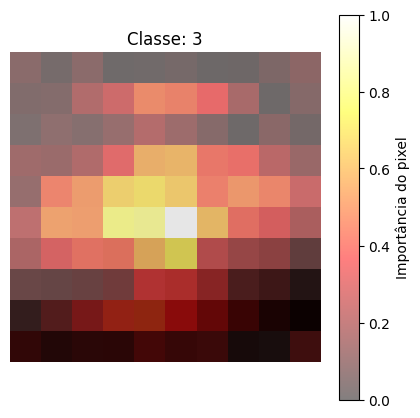

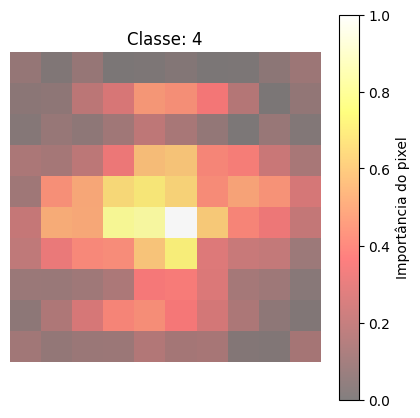

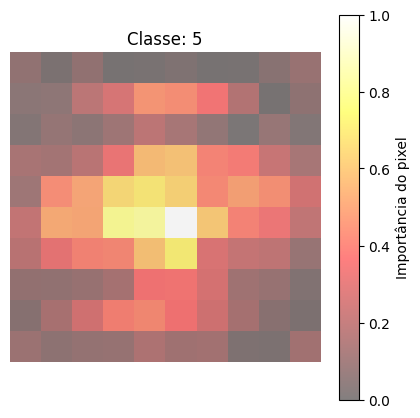

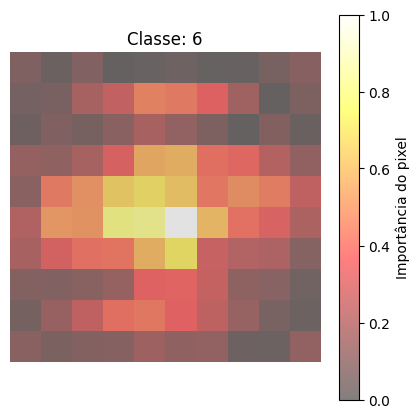

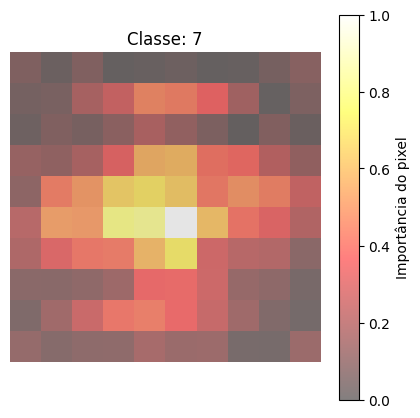

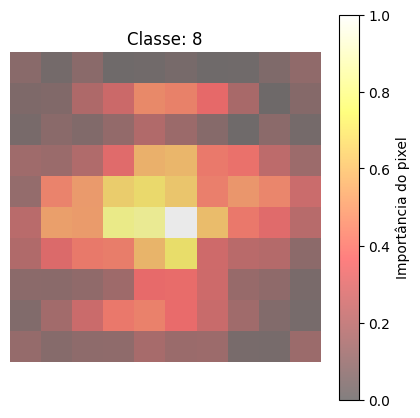

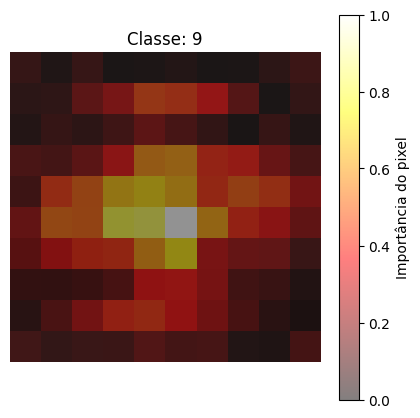

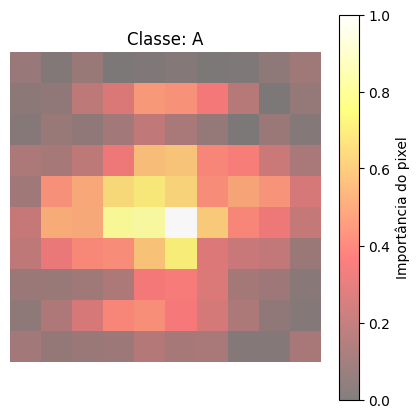

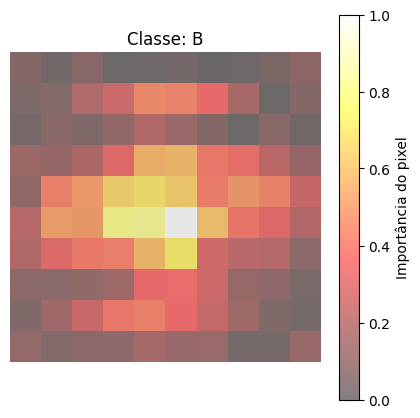

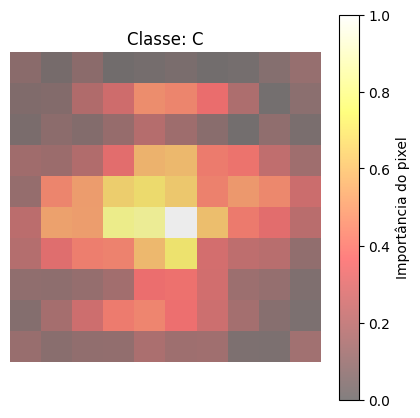

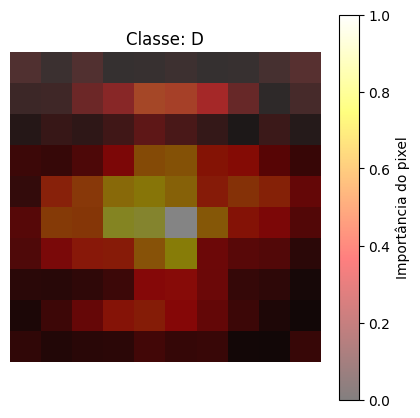

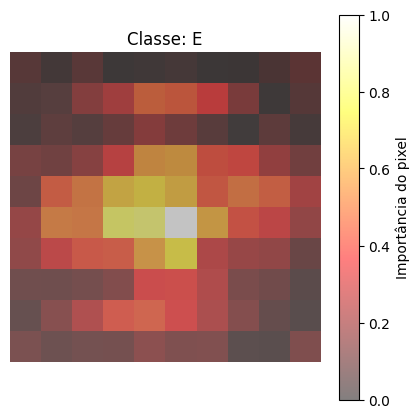

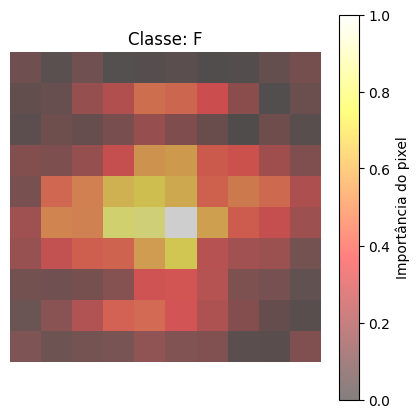

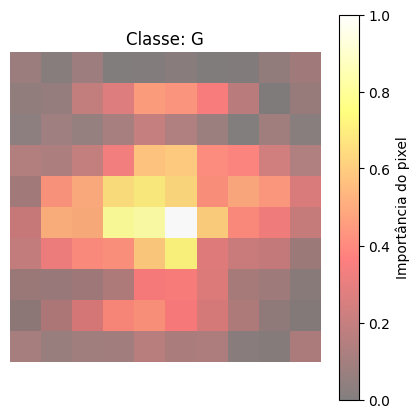

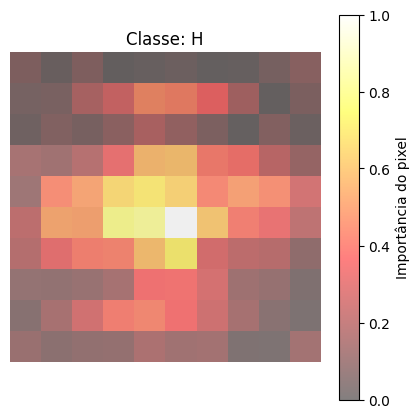

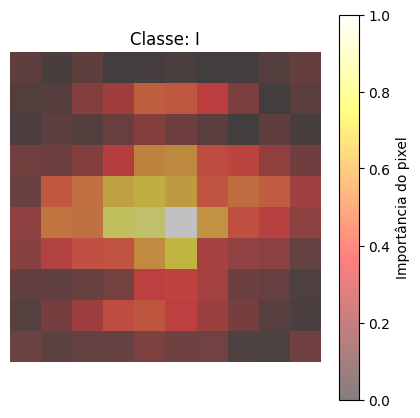

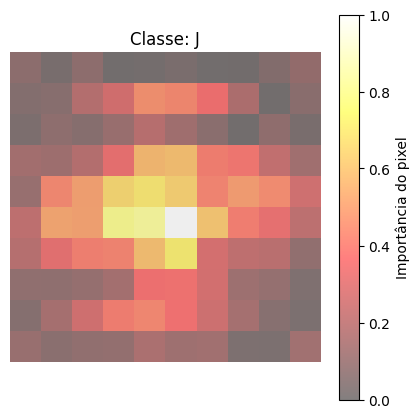

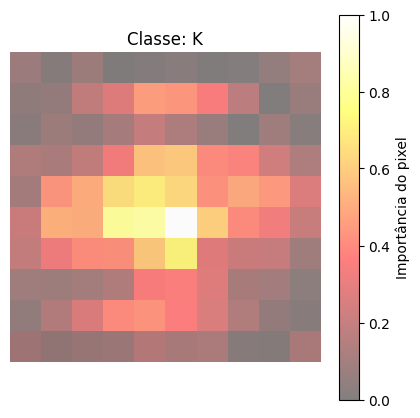

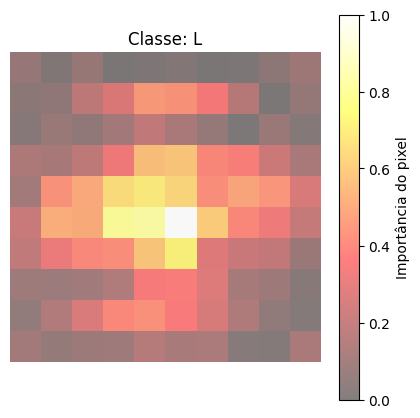

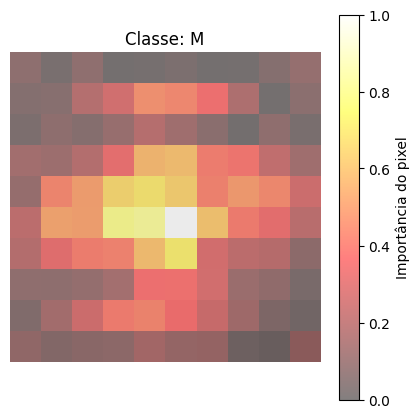

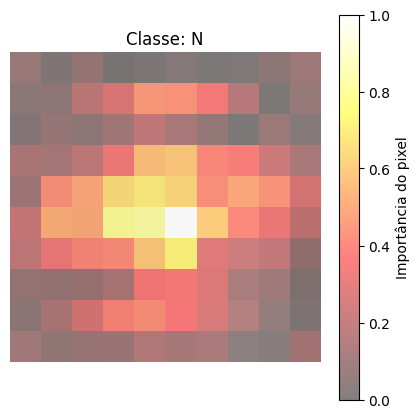

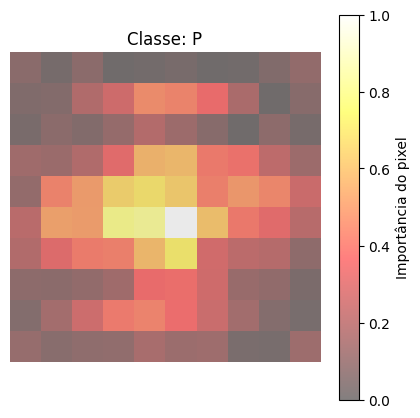

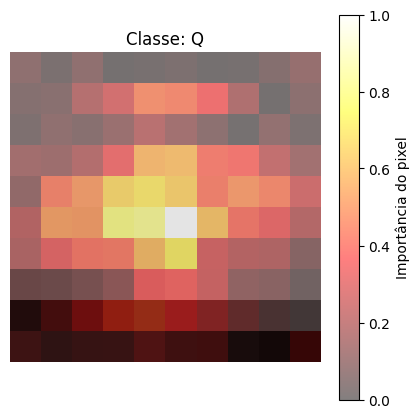

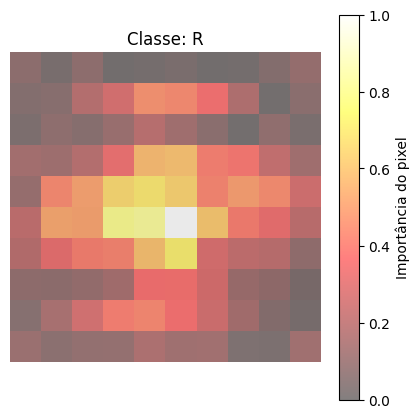

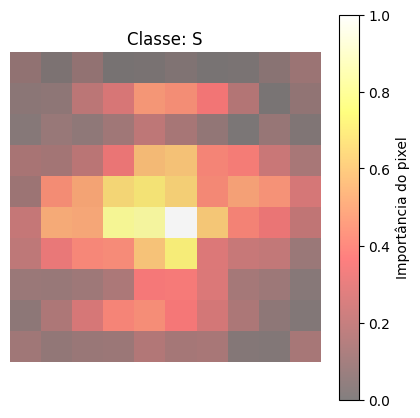

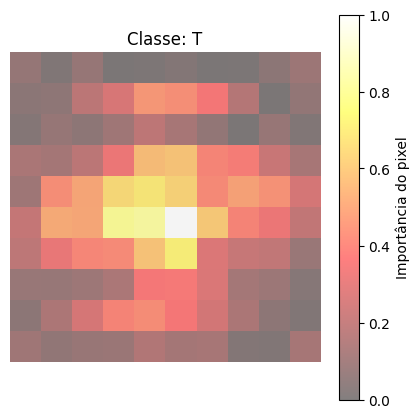

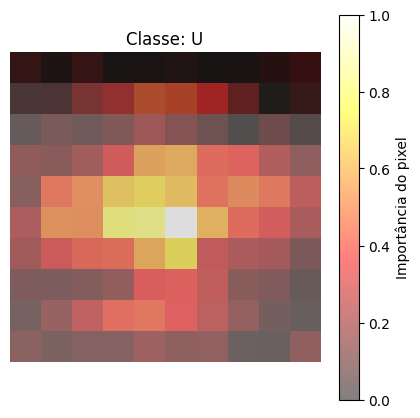

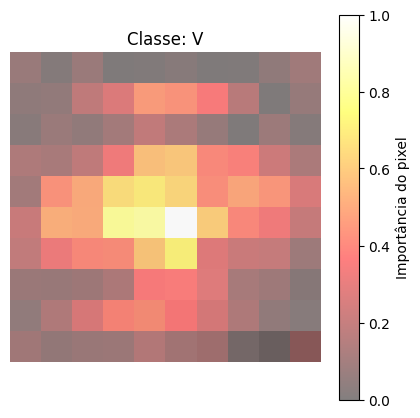

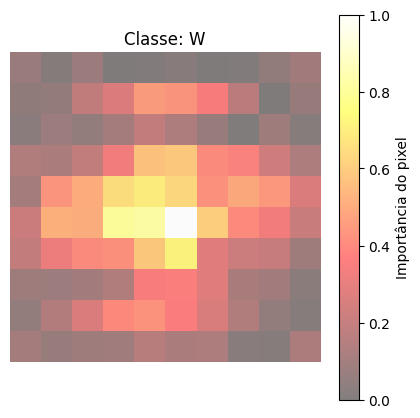

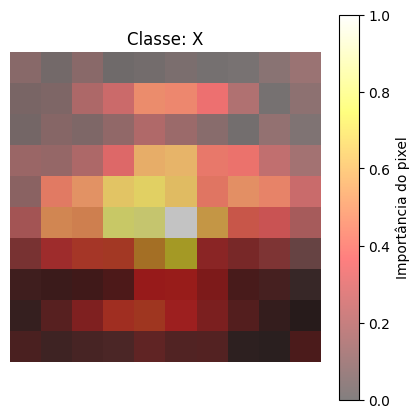

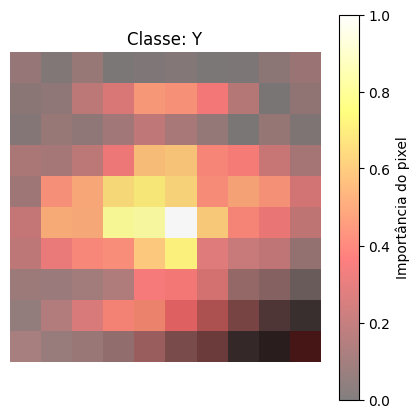

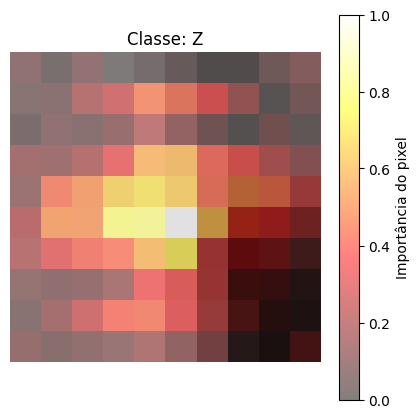

In [136]:
import matplotlib.pyplot as plt

# Normaliza o mapa de importância
pixel_importance_norm = (pixel_importance - pixel_importance.min()) / \
                        (pixel_importance.max() - pixel_importance.min())

for class_name, class_idx in train_data.class_to_idx.items():
    for img, label in train_data:
        if label == class_idx:
            break

    plt.figure(figsize=(5,5))
    plt.imshow(img.squeeze().cpu(), cmap='gray')                      # imagem na CPU
    plt.imshow(pixel_importance_norm.cpu(), cmap='hot', alpha=0.5)   # mapa de importância na CPU
    plt.title(f'Classe: {class_name}')
    plt.colorbar(label='Importância do pixel')
    plt.axis('off')
    plt.show()


In [137]:
H, W = pixel_importance.shape  # agora H=W=new_dimension
num_top_pixels = new_dimension * new_dimension

# Flatten
pixel_importance_flat = pixel_importance.flatten()

# Top pixels
top_pixel_indices = torch.argsort(pixel_importance_flat, descending=True)[:num_top_pixels]

# Converte para coordenadas 2D corretas no novo espaço
top_pixel_coordinates = [(i // W, i % W) for i in top_pixel_indices]

# Inteiros na CPU
top_pixel_coordinates_int = [(int(r.cpu()), int(c.cpu())) for r, c in top_pixel_coordinates]

print(top_pixel_coordinates_int[:10])
print(f"Número total de pixels selecionados: {len(top_pixel_coordinates_int)}")


[(5, 5), (5, 4), (5, 3), (6, 5), (4, 4), (4, 3), (4, 5), (5, 6), (3, 5), (6, 4)]
Número total de pixels selecionados: 100


In [138]:

#print(f"Top {num_top_pixels} most important pixel coordinates (row, col):")
#for coord in top_pixel_coordinates:
#    print(coord)

# Teste

## Primeira Etapa
- Carregar o dataset de teste (MNIST)
- Iterar sobre os dados e construir os batchs

In [139]:
# A quinta célula (nof7Z6R1cEaz) importa datasets, transforms e DataLoader do torchvision e torch.utils.data.
# Ela baixa e carrega o conjunto de dados MNIST para teste (te_data) e cria um DataLoader para iterar sobre os dados de teste em lotes (te_loader).

#test_loader ja foi carregado

## Segunda Etapa
- desativa camadas que não são usadas no teste
- desativa o calculo de gradiente (pois pesos não serão mais atualizados)
- passa a imagem na rede totalmente conectada
- calcula loss (quão distante predições estão dos rótulos reais)
- retorna média de perdas por batch

### Calculo de Loss

In [140]:
# A sexta célula (MIJUYZY9cMsm) define a função calc_loss que calcula a perda média em um conjunto de dados usando o
# modelo e a função de perda fornecidos. Ela coloca o modelo em modo de avaliação (model.eval()) e desativa o cálculo
# de gradientes (torch.no_grad()) para economizar memória e computação durante a avaliação.

def calc_loss(model, criterion, loader, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    #device = "cpu"
    batch_losses = []
    model.eval()
    model.to(device)  # garante que o modelo está na GPU ou CPU escolhida

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)                   # Flatten já está no modelo
            loss = criterion(output, label_batch).item()  # converte para float
            batch_losses.append(loss)

    mean_loss = sum(batch_losses) / len(batch_losses)
    return batch_losses, mean_loss


In [141]:
from torch.nn import CrossEntropyLoss

criterion = CrossEntropyLoss()
batch_losses, mean_loss = calc_loss(model, criterion, test_loader)
print(f"Loss média no conjunto de teste: {mean_loss:.4f}")
print(f"Loss por batch (primeiros 5): {batch_losses[:10]}")



Loss média no conjunto de teste: 0.2629
Loss por batch (primeiros 5): [0.2267351895570755, 0.9697028994560242, 0.9957151412963867, 0.08639465272426605, 1.6821553707122803, 0.14139750599861145, 0.29260969161987305, 0.4546671509742737, 0.23319801688194275, 0.4035944938659668]


In [142]:
# A oitava célula (VOIPL7kkccX2) importa numpy, seleciona a primeira imagem e seu
# rótulo do conjunto de dados de teste, passa a imagem pelo modelo para obter uma
# previsão e imprime o rótulo real, a saída do modelo (logits) e o rótulo previsto (o índice com o maior logit).
import torch
import numpy as np


# Seleciona a primeira imagem do dataset de teste
img, label = test_data[0]

# Move para o mesmo device do modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"

img = img.to(device).unsqueeze(0)  # adiciona dimensão batch: (1, C, H, W)
model = model.to(device)

# Coloca o modelo em modo avaliação
model.eval()
with torch.no_grad():
    pred = model(img)                 # Flatten já está no modelo
    predicted_label_idx = pred.argmax(dim=1).item()  # índice do logit mais alto

# Mostra resultados
print(f"Label real: {test_data.classes[label]}")
print(f"Logits: {pred}")
print(f"Label previsto: {test_data.classes[predicted_label_idx]}")


Label real: 0
Logits: tensor([[ 11.4497,  -6.0132,   4.7007,  -3.4563,  -3.7519,  -2.1477,   2.7013,
          -0.1121,   1.0908,  -1.4260,  -2.1360,   3.3489,   7.8709,   8.4275,
          -1.6469,  -5.2666,   5.9670,   0.9341,  -7.5481,   0.4476,  -5.3783,
           0.9941,   2.9955,   1.4883,  -1.1746,   8.2549,   0.8827,  -1.7569,
          -5.7262,   8.4910,  -5.6377,   4.4031, -10.9840,  -8.7615,  -1.7348]],
       device='cuda:0')
Label previsto: 0


### Calculo da Acurácia

In [143]:
def calc_accuracy(model, loader, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    n_classes = len(train_data.classes)
    correct_total = 0
    total_total = 0
    correct_per_class = {i: 0 for i in range(n_classes)}
    total_per_class = {i: 0 for i in range(n_classes)}

    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    #device = "cpu"
    model.to(device)

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)
            preds = output.argmax(dim=1)

            correct_total += (preds == label_batch).sum().item()
            total_total += len(label_batch)

            # Acertos por classe
            for i in range(len(label_batch)):
                label = label_batch[i].item()
                total_per_class[label] += 1
                if preds[i] == label_batch[i]:
                    correct_per_class[label] += 1

    # Calcula acurácia por classe
    class_acc = {
        train_data.classes[cls]: correct_per_class[cls] / total_per_class[cls] 
        if total_per_class[cls] > 0 else 0
        for cls in range(n_classes)
    }

    overall_acc = correct_total / total_total
    return overall_acc, class_acc


In [144]:
# Calcula acurácia usando o DataLoader de teste
overall_acc, class_acc = calc_accuracy(model, test_loader)

# Acurácia geral
print(f"Acurácia geral: {overall_acc*100:.2f}%")

# Acurácia por classe
for cls_name, acc in class_acc.items():
    print(f"Classe {cls_name}: {acc*100:.2f}%")


Acurácia geral: 93.41%
Classe 0: 89.32%
Classe 1: 81.55%
Classe 2: 93.69%
Classe 3: 95.15%
Classe 4: 93.69%
Classe 5: 98.06%
Classe 6: 94.66%
Classe 7: 96.60%
Classe 8: 73.30%
Classe 9: 95.63%
Classe A: 98.02%
Classe B: 87.38%
Classe C: 99.51%
Classe D: 99.01%
Classe E: 93.56%
Classe F: 98.53%
Classe G: 96.57%
Classe H: 99.51%
Classe I: 82.18%
Classe J: 97.09%
Classe K: 98.02%
Classe L: 93.07%
Classe M: 100.00%
Classe N: 93.14%
Classe P: 99.01%
Classe Q: 79.21%
Classe R: 96.57%
Classe S: 95.10%
Classe T: 97.55%
Classe U: 95.54%
Classe V: 87.38%
Classe W: 97.52%
Classe X: 97.52%
Classe Y: 79.21%
Classe Z: 98.77%


# Treinamento Reduzido


Função que reduz imagem original


In [145]:
import torch.nn.functional as F

def reduce_image(img_tensor, coords, new_dim=new_dimension):
    """
    Recebe uma imagem [C,H,W] ou [H,W] e retorna vetor [num_top_pixels]
    contendo apenas os pixels mais importantes no novo espaço.
    """
    # Remove canal se necessário
    img = img_tensor.squeeze()  # [H, W]

    # Resize para new_dim x new_dim
    img_resized = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(new_dim, new_dim), mode='bilinear', align_corners=False).squeeze()

    # Seleciona os pixels importantes
    return torch.tensor([img_resized[r, c].item() for r, c in coords])


## Primeira Etapa
- Criar dataset MNIST reduzido
- Já gera o dataset como vetor 1D

In [146]:
from torch.utils.data import TensorDataset, DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reduz conjunto de treino
X_train_reduced = torch.stack([reduce_image(img, top_pixel_coordinates_int) for img, _ in train_data])
y_train = torch.tensor([label for _, label in train_data])


# Reduz conjunto de teste
X_test_reduced = torch.stack([reduce_image(img, top_pixel_coordinates_int) for img, _ in test_data])
y_test = torch.tensor([label for _, label in test_data])

print(f"Novo shape de treino: {X_train_reduced.shape}")
print(f"Novo shape de teste:  {X_test_reduced.shape}")

# DataLoaders
batch_size = 10
train_loader_reduced = DataLoader(TensorDataset(X_train_reduced, y_train), batch_size=batch_size, shuffle=True)
test_loader_reduced = DataLoader(TensorDataset(X_test_reduced, y_test), batch_size=batch_size)


Novo shape de treino: torch.Size([28400, 100])
Novo shape de teste:  torch.Size([7100, 100])


## Segunda etapa
- criar modelo reduzido


In [147]:
import torch.nn as nn

num_pixels = new_dimension * new_dimension  # entrada reduzida
n_classes = len(train_data.classes)         # número de classes reais

model_small = nn.Sequential(
    nn.Linear(num_pixels, n_classes)
)


## Terceira etapa
- realizar treinamento

In [148]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
model_small.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_small.parameters(), lr=0.1)

epochs = 5
losses_reduced = []

for epoch in range(epochs):
    print(f'Epoch: {epoch}')
    model_small.train()
    total_loss = 0
    
    for X_batch, y_batch in tqdm(train_loader_reduced):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model_small(X_batch)
        loss = criterion(output, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    
    losses_reduced.append(total_loss / len(train_loader_reduced))
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader_reduced):.4f}")


Epoch: 0


100%|█████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:01<00:00, 1432.06it/s]


Epoch 1, Loss: 1.8709
Epoch: 1


100%|█████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:02<00:00, 1258.64it/s]


Epoch 2, Loss: 0.9470
Epoch: 2


...

Epoch 3, Loss: 0.7302
Epoch: 3


100%|█████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:01<00:00, 1501.57it/s]


Epoch 4, Loss: 0.6252
Epoch: 4


100%|█████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:01<00:00, 1492.99it/s]

Epoch 5, Loss: 0.5588


In [149]:
#printa as perdas

print(losses_reduced)


[1.8709133560598736, 0.9469869802430482, 0.7302091189988063, 0.6252461241636897, 0.5587743217781396]


# Importancia Pixels Reduzido

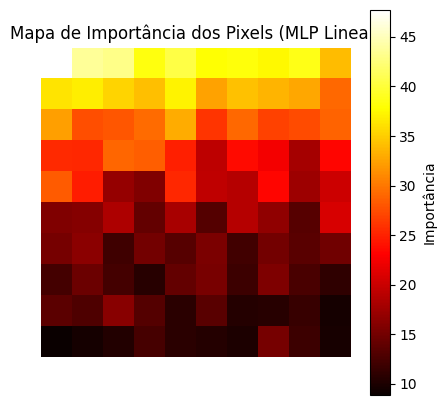

In [150]:
import torch
import matplotlib.pyplot as plt

model_small.eval()
with torch.no_grad():
    # pega os pesos da primeira camada
    weights = model_small[0].weight.data  # [n_classes, num_pixels]

    # soma absoluta ao longo das classes
    pixel_importance = torch.sum(torch.abs(weights), dim=0)

    # reshape para new_dimension x new_dimension (entrada reduzida)
    pixel_importance = pixel_importance.reshape(new_dimension, new_dimension).cpu()

# plot
plt.figure(figsize=(5,5))
plt.imshow(pixel_importance, cmap='hot')
plt.title("Mapa de Importância dos Pixels (MLP Linear)")
plt.colorbar(label='Importância')
plt.axis('off')
plt.show()


# Teste reduzido

## Primeira Etapa
Carregar dataset para teste reduzido

In [151]:
from torch.utils.data import TensorDataset, DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Lista de imagens reduzidas usando as coordenadas corretas
X_test_reduced = torch.stack([reduce_image(img, top_pixel_coordinates_int) for img, _ in test_data])
y_test = torch.tensor([label for _, label in test_data])

print(f"Shape do dataset reduzido: {X_test_reduced.shape}")  # deve ser (N_test, num_top_pixels)

# DataLoader para o modelo reduzido
test_loader_reduced = DataLoader(
    TensorDataset(X_test_reduced, y_test),
    batch_size=10,  # ou outro batch_size que quiser
    shuffle=False
)


Shape do dataset reduzido: torch.Size([7100, 100])


## Segunda etapa
- desativa camadas que não são usadas no teste
- desativa o calculo de gradiente (pois pesos não serão mais atualizados)
- passa a imagem na rede totalmente conectada
- calcula loss (quão distante predições estão dos rótulos reais)
- retorna média de perdas por batch

In [152]:
def calc_loss_reduced(model, criterion, loader):
    """
    Calcula a loss média de um modelo MLP que recebe entradas já achatadas.
    loader: DataLoader do dataset reduzido (ex: test_loader_reduced)
    """
    batch_losses = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)
            loss = criterion(output, label_batch).item()
            batch_losses.append(loss)

    mean_loss = sum(batch_losses) / len(batch_losses)
    return batch_losses, mean_loss


In [153]:
batch_losses_reduced, mean_loss_reduced = calc_loss_reduced(model_small, criterion, test_loader_reduced)

print(f"Loss média: {mean_loss_reduced:.4f}")
print(f"Loss por batch (primeiros 5): {batch_losses_reduced[:10]}")


Loss média: 0.5531
Loss por batch (primeiros 5): [0.5750465989112854, 0.9090544581413269, 1.056443452835083, 0.2797407805919647, 2.012652635574341, 0.6304723024368286, 0.5356666445732117, 0.9276901483535767, 0.4756705164909363, 0.6456605195999146]


In [154]:
#device = next(model_small.parameters()).device
#img = img.to(device)
#label = label.to(device)
#pred = model_small(img.unsqueeze(0))


In [155]:
def calc_accuracy_reduced(model, loader, n_classes=None):
    """
    Calcula acurácia geral e por classe de um modelo MLP.
    loader: DataLoader do dataset reduzido.
    n_classes: número de classes (se None, inferido do loader).
    """
    if n_classes is None:
        n_classes = len(loader.dataset.tensors[1].unique())
    
    correct_total = 0
    total_total = 0
    correct_per_class = {i: 0 for i in range(n_classes)}
    total_per_class = {i: 0 for i in range(n_classes)}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)
            preds = output.argmax(dim=1)

            correct_total += (preds == label_batch).sum().item()
            total_total += len(label_batch)

            for i in range(len(label_batch)):
                label = label_batch[i].item()
                total_per_class[label] += 1
                if preds[i] == label_batch[i]:
                    correct_per_class[label] += 1

    class_acc = {cls: correct_per_class[cls]/total_per_class[cls] 
                 if total_per_class[cls] > 0 else 0
                 for cls in range(n_classes)}

    overall_acc = correct_total / total_total
    return overall_acc, class_acc


In [156]:
overall_acc_reduced, class_acc_reduced = calc_accuracy_reduced(model_small, test_loader_reduced)

print(f"Acurácia geral: {overall_acc_reduced*100:.2f}%")
for cls, acc in class_acc_reduced.items():
    print(f"Classe {cls}: {acc*100:.2f}%")


Acurácia geral: 88.39%
Classe 0: 87.38%
Classe 1: 87.38%
Classe 2: 94.66%
Classe 3: 90.78%
Classe 4: 93.69%
Classe 5: 92.72%
Classe 6: 84.47%
Classe 7: 83.50%
Classe 8: 69.42%
Classe 9: 94.17%
Classe 10: 86.63%
Classe 11: 76.21%
Classe 12: 95.59%
Classe 13: 94.55%
Classe 14: 89.60%
Classe 15: 98.53%
Classe 16: 98.04%
Classe 17: 94.61%
Classe 18: 50.00%
Classe 19: 98.06%
Classe 20: 95.05%
Classe 21: 95.54%
Classe 22: 92.65%
Classe 23: 93.14%
Classe 24: 88.61%
Classe 25: 62.38%
Classe 26: 90.69%
Classe 27: 91.67%
Classe 28: 88.24%
Classe 29: 85.64%
Classe 30: 80.58%
Classe 31: 95.05%
Classe 32: 91.58%
Classe 33: 86.63%
Classe 34: 98.15%


# Treinamento Reduzido Random

In [157]:
import torch
import random

# Tamanho da imagem
H, W = 75, 100  # ou use train_data[0][0].shape[1], shape[2]

# Número de pixels que queremos manter
num_pixels_random = new_dimension * new_dimension  # por exemplo 16*16 = 256

# Todos os índices possíveis da imagem achatada
all_indices = list(range(H * W))

# Seleciona aleatoriamente
random_indices = random.sample(all_indices, num_pixels_random)

# Converter para coordenadas 2D
random_coords = [(i // W, i % W) for i in random_indices]

# Mostrar os 10 primeiros
print(random_coords[:10])
print(len(random_coords))


[(5, 10), (20, 55), (40, 67), (67, 79), (58, 10), (55, 74), (56, 20), (72, 30), (56, 90), (71, 45)]
100


In [158]:
import torch

def reduce_image_random(img_tensor, coords):
    """
    Recebe uma imagem [C, H, W] e devolve tensor [num_top_pixels]
    contendo apenas os pixels nas coordenadas desejadas.
    """
    # remove canal se for 1
    img = img_tensor.squeeze()  # [H, W]
    
    # transforma coords em dois vetores de índices
    rows = torch.tensor([r for r, _ in coords], dtype=torch.long, device=img.device)
    cols = torch.tensor([c for _, c in coords], dtype=torch.long, device=img.device)
    
    # indexação vetorizada (sem loops, sem .item())
    values = img[rows, cols]
    
    return values  # já é tensor, sem conversão extra

X_train_random = torch.stack([
    reduce_image_random(img, random_coords) for img, _ in train_data
])
y_train = torch.tensor([label for _, label in train_data], dtype=torch.long)

X_test_random = torch.stack([
    reduce_image_random(img, random_coords) for img, _ in test_data
])
y_test = torch.tensor([label for _, label in test_data], dtype=torch.long)


In [159]:
from torch.utils.data import DataLoader, TensorDataset

train_loader_random = DataLoader(TensorDataset(X_train_random, y_train), batch_size=10, shuffle=True)
test_loader_random = DataLoader(TensorDataset(X_test_random, y_test), batch_size=10, shuffle=False)


In [160]:
import torch.nn as nn
from tqdm import tqdm
n_classes = len(train_data.classes)         # número de classes reais

num_pixels = new_dimension * new_dimension
model_random = nn.Sequential(
    nn.Linear(num_pixels, n_classes)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_random.parameters(), lr=0.1)

# Se quiser treinar na GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#device =  'cpu'
model_random.to(device)

epochs = 5
losses_random = []

for epoch in range(epochs):
    print(f'Epoch: {epoch}')
    model_random.train()
    total_loss = 0

    for X_batch, y_batch in tqdm(train_loader_random):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model_random(X_batch)
        loss = criterion(output, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    losses_random.append(total_loss / len(train_loader_random))
    print(f"Epoch {epoch+1}, Loss média: {losses_random[-1]:.4f}")


Epoch: 0


100%|██████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:08<00:00, 347.13it/s]


Epoch 1, Loss média: 1.9615
Epoch: 1


100%|██████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:06<00:00, 451.98it/s]


Epoch 2, Loss média: 1.0868
Epoch: 2


...

Epoch 3, Loss média: 0.8739
Epoch: 3


100%|██████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:05<00:00, 487.11it/s]


Epoch 4, Loss média: 0.7666
Epoch: 4


100%|██████████████████████████████████████████████████████████████████████████████| 2840/2840 [00:05<00:00, 484.01it/s]

Epoch 5, Loss média: 0.6986


# Importancia Pixels Random

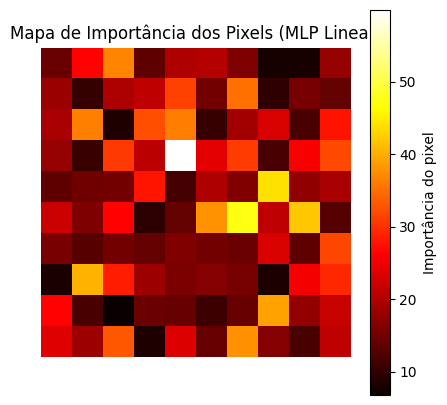

In [161]:
import torch
import matplotlib.pyplot as plt

# Coloca o modelo em avaliação
model_random.eval()

# Se estiver usando GPU, mova os pesos para CPU
with torch.no_grad():
    # Pega os pesos da primeira camada linear e garante que estão na CPU
    weights = model_random[0].weight.data.cpu()  # shape [n_classes, num_pixels]

    # Calcula a importância dos pixels (soma dos valores absolutos para cada pixel)
    pixel_importance = torch.sum(torch.abs(weights), dim=0)  # shape [num_pixels]

    # Reshape para [new_dimension, new_dimension]
    pixel_importance = pixel_importance.reshape(new_dimension, new_dimension)

# Plota o mapa de importância
plt.figure(figsize=(5,5))
plt.imshow(pixel_importance, cmap='hot')
plt.title("Mapa de Importância dos Pixels (MLP Linear)")
plt.colorbar(label='Importância do pixel')
plt.axis('off')
plt.show()


# Teste Reduzido Random

In [162]:
from torch.utils.data import DataLoader, TensorDataset

# DataLoader para o dataset com pixels aleatórios
test_loader_random = DataLoader(
    TensorDataset(X_test_random, y_test),  # tensores já processados
    batch_size=10,                         # mantém mesmo batch size dos outros loaders
    shuffle=False                           # teste não precisa embaralhar
)


In [163]:
overall_acc_random, class_acc_random = calc_accuracy_reduced(
    model_random, test_loader_random
)

print(f"Acurácia geral (pixels aleatórios): {overall_acc_random*100:.2f}%")
for cls, acc in class_acc_random.items():
    print(f"Classe {cls}: {acc*100:.2f}%")


Acurácia geral (pixels aleatórios): 84.18%
Classe 0: 82.52%
Classe 1: 91.26%
Classe 2: 82.04%
Classe 3: 86.89%
Classe 4: 90.78%
Classe 5: 89.81%
Classe 6: 65.05%
Classe 7: 77.67%
Classe 8: 58.25%
Classe 9: 86.41%
Classe 10: 85.64%
Classe 11: 66.02%
Classe 12: 94.12%
Classe 13: 90.10%
Classe 14: 86.14%
Classe 15: 94.61%
Classe 16: 87.25%
Classe 17: 93.63%
Classe 18: 39.11%
Classe 19: 96.60%
Classe 20: 98.51%
Classe 21: 91.58%
Classe 22: 93.14%
Classe 23: 87.25%
Classe 24: 80.69%
Classe 25: 69.80%
Classe 26: 87.75%
Classe 27: 91.18%
Classe 28: 83.82%
Classe 29: 84.16%
Classe 30: 82.52%
Classe 31: 85.64%
Classe 32: 91.58%
Classe 33: 81.19%
Classe 34: 96.30%


In [164]:
batch_losses_random, mean_loss_random = calc_loss_reduced(
    model_random, criterion, test_loader_random
)

print(f"Loss média (pixels aleatórios): {mean_loss_random:.4f}")
print(f"Loss por batch (primeiros 5): {batch_losses_random[:5]}")


Loss média (pixels aleatórios): 0.6798
Loss por batch (primeiros 5): [0.7298499345779419, 0.990486741065979, 1.5461879968643188, 0.43528634309768677, 1.9758193492889404]


# Análises


TODO: fazer os testes várias vezes e usar a media

In [165]:
import pandas as pd

# Exemplo de dados (substitua pelos valores reais)
results = {
    "Modelo": ["75x100", "16x16 (inteligente)", "16x16 (aleatório)"],
    "Pixels": [7500, 256, 256],
    "Acurácia geral (%)": [overall_acc*100, overall_acc_reduced*100, overall_acc_random*100],
    "Loss média": [mean_loss, mean_loss_reduced, mean_loss_random]
}

df = pd.DataFrame(results)
print(df)


                Modelo  Pixels  Acurácia geral (%)  Loss média
0               75x100    7500           93.408451    0.262890
1  16x16 (inteligente)     256           88.394366    0.553114
2    16x16 (aleatório)     256           84.183099    0.679775


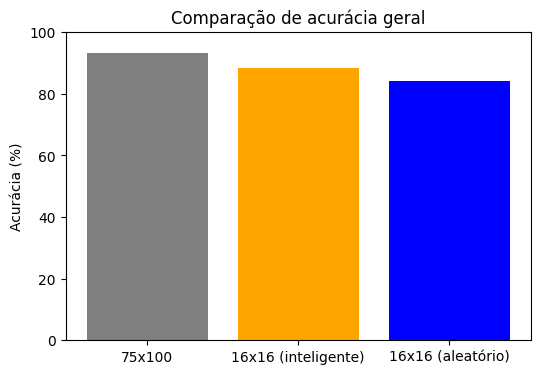

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    results["Modelo"],
    results["Acurácia geral (%)"],
    color=['gray','orange','blue']
)
plt.ylabel("Acurácia (%)")
plt.title("Comparação de acurácia geral")
plt.ylim(0, 100)
plt.show()


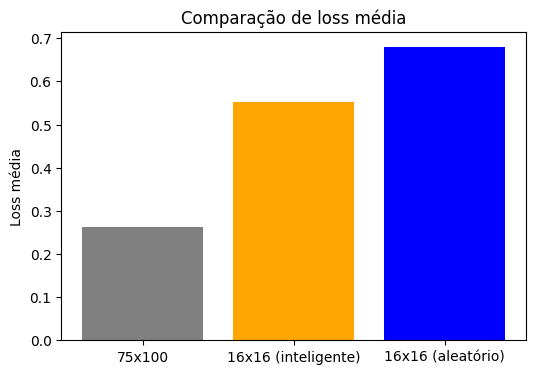

In [167]:
plt.figure(figsize=(6,4))
plt.bar(
    results["Modelo"],
    results["Loss média"],
    color=['gray','orange','blue']
)
plt.ylabel("Loss média")
plt.title("Comparação de loss média")
plt.show()


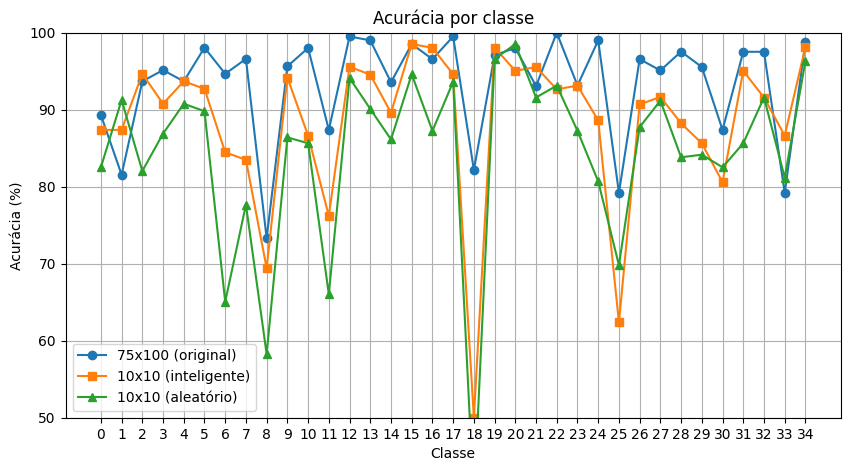

In [168]:
import numpy as np
import matplotlib.pyplot as plt

# Número de classes
classes = list(range(len(class_acc)))

# Converte os dicionários de acurácia em arrays NumPy
acc_matrix = np.array([
    [v for v in class_acc.values()],
    [v for v in class_acc_reduced.values()],
    [v for v in class_acc_random.values()]
])

# Multiplica por 100 para porcentagem
acc_matrix *= 100

# Plota
plt.figure(figsize=(10,5))
plt.plot(classes, acc_matrix[0], marker='o', label='75x100 (original)')
plt.plot(classes, acc_matrix[1], marker='s', label=f'{new_dimension}x{new_dimension} (inteligente)')
plt.plot(classes, acc_matrix[2], marker='^', label=f'{new_dimension}x{new_dimension} (aleatório)')

plt.xlabel("Classe")
plt.ylabel("Acurácia (%)")
plt.title("Acurácia por classe")
plt.xticks(classes)
plt.ylim(50, 100)
plt.legend()
plt.grid(True)
plt.show()


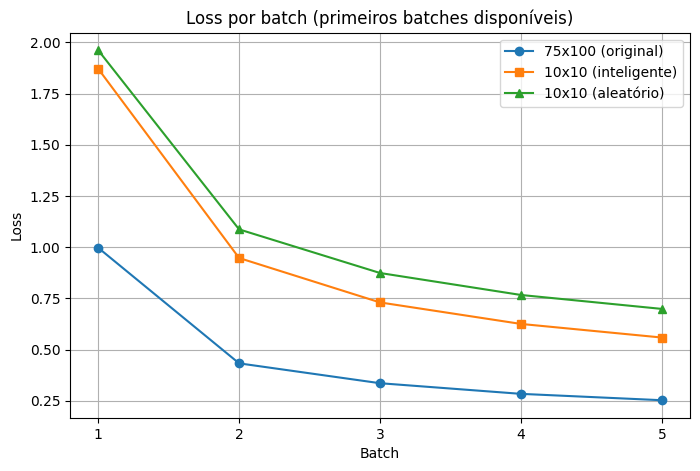

In [169]:
import matplotlib.pyplot as plt

# Lista de losses por batch
# losses (modelo original), losses_reduced (pixels inteligentes), losses_random (pixels aleatórios)

# Determina o número de batches disponíveis em cada lista
num_batches_full = len(losses)
num_batches_reduced = len(losses_reduced)
num_batches_random = len(losses_random)

# Queremos plotar no máximo 10 batches
num_batches_to_plot = min(10, num_batches_full, num_batches_reduced, num_batches_random)

batches = range(1, num_batches_to_plot + 1)

plt.figure(figsize=(8,5))

# Plota cada modelo
plt.plot(batches, losses[:num_batches_to_plot], marker='o', label='75x100 (original)')
plt.plot(batches, losses_reduced[:num_batches_to_plot], marker='s', label=f'{new_dimension}x{new_dimension} (inteligente)')
plt.plot(batches, losses_random[:num_batches_to_plot], marker='^', label=f'{new_dimension}x{new_dimension} (aleatório)')

plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Loss por batch (primeiros batches disponíveis)')
plt.xticks(batches)
plt.legend()
plt.grid(True)
plt.show()
